In [1]:
import numpy as np
import bsf
import esm
import torch

In [30]:
!wget https://ftp.ensembl.org/pub/release-116/fasta/homo_sapiens/pep/Homo_sapiens.GRCh38.pep.all.fa.gz
!gunzip Homo_sapiens.GRCh38.pep.all.fa.gz

--2026-07-10 16:13:07--  https://ftp.ensembl.org/pub/release-116/fasta/homo_sapiens/pep/Homo_sapiens.GRCh38.pep.all.fa.gz
Resolving ftp.ensembl.org (ftp.ensembl.org)... 193.62.193.169
Connecting to ftp.ensembl.org (ftp.ensembl.org)|193.62.193.169|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23319936 (22M) [application/x-gzip]
Saving to: ‘Homo_sapiens.GRCh38.pep.all.fa.gz’

Homo_sapiens.GRCh38 100%[===================>]  22.24M  61.6MB/s    in 0.4s    

2026-07-10 16:13:08 (61.6 MB/s) - ‘Homo_sapiens.GRCh38.pep.all.fa.gz’ saved [23319936/23319936]



In [2]:
def load_fasta_as_dict(fasta_path, max_length=1024):
    proteins = {}
    current_header = None
    current_sequence = []

    with open(fasta_path, "r") as fasta_file:
        for line in fasta_file:
            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):
                # Save the previous sequence
                if current_header is not None:
                    sequence = "".join(current_sequence)

                    if len(sequence) <= max_length:
                        proteins[current_header] = sequence

                current_header = line[1:]
                current_sequence = []

            else:
                current_sequence.append(line)

        # Save the final sequence
        if current_header is not None:
            sequence = "".join(current_sequence)

            if len(sequence) <= max_length:
                proteins[current_header] = sequence

    return proteins

In [3]:
fasta_path = "../../Homo_sapiens.GRCh38.pep.all.fa"
all_proteins = load_fasta_as_dict(fasta_path)
tenk_proteins = dict(list(all_proteins.items())[:10000])

In [4]:
standard_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

ten_proteins = {
    protein_id: "".join(
        aa for aa in sequence.upper()
        if aa in standard_amino_acids
    )
    for protein_id, sequence in tenk_proteins.items()
}

In [5]:
# Load ESM-2 model
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

model = model.to(device)

print("model load successfull")



Using: cuda
model load successfull


In [7]:
all_data = list(ten_proteins.items())

sequence_representations = []

batch_size = 128
for start in range(0, len(all_data), batch_size):
    batch_data = all_data[start : start + batch_size]
    batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
    batch_lens = (batch_tokens != alphabet.padding_idx).sum(1)

    batch_tokens = batch_tokens.to(device)


    # Extract per-residue representations (on CPU)
    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[33], return_contacts=False)
    token_representations = results["representations"][33]

    # Generate per-sequence representations via averaging
    # NOTE: token 0 is always a beginning-of-sequence token, so the first residue is token 1.

    for i, tokens_len in enumerate(batch_lens):
        sequence_representations.append(token_representations[i, 1 : tokens_len - 1].mean(0))

In [13]:
sequence_representations = torch.stack(sequence_representations)
norm_sequence_representations = sequence_representations - sequence_representations.mean(dim=0)
x = norm_sequence_representations
x = x.cpu()
x = (x / np.sqrt((x**2).sum(1).mean()))*(np.sqrt(x.shape[1]))
x = x.cuda()

In [15]:
model = bsf.GrassmannianBSF(d=x.shape[1], n_groups=256, group_size=3, l0=8)
bsf.train(model, x, epochs=300, lr=3e-3)

epoch   1/300   loss=0.8244   R2=0.3481   L0=8.0   dead=0/256
epoch   5/300   loss=0.2714   R2=0.7540   L0=8.0   dead=1/256
epoch  10/300   loss=0.1593   R2=0.8484   L0=8.0   dead=5/256
epoch  15/300   loss=0.1259   R2=0.8781   L0=8.0   dead=6/256
epoch  20/300   loss=0.1089   R2=0.8935   L0=8.0   dead=12/256
epoch  25/300   loss=0.0990   R2=0.9030   L0=8.0   dead=14/256
epoch  30/300   loss=0.0918   R2=0.9094   L0=8.0   dead=16/256
epoch  35/300   loss=0.0866   R2=0.9145   L0=8.0   dead=15/256
epoch  40/300   loss=0.0831   R2=0.9184   L0=8.0   dead=16/256
epoch  45/300   loss=0.0796   R2=0.9215   L0=8.0   dead=16/256
epoch  50/300   loss=0.0769   R2=0.9240   L0=8.0   dead=18/256
epoch  55/300   loss=0.0753   R2=0.9264   L0=8.0   dead=16/256
epoch  60/300   loss=0.0729   R2=0.9284   L0=8.0   dead=18/256
epoch  65/300   loss=0.0710   R2=0.9301   L0=8.0   dead=16/256
epoch  70/300   loss=0.0689   R2=0.9318   L0=8.0   dead=17/256
epoch  75/300   loss=0.0679   R2=0.9333   L0=8.0   dead=17/

GrassmannianBSF()

In [16]:
# Encode every patch -> (N, G, K) codes; atoms are the decoder blocks (G, K, d).
device = next(model.parameters()).device
z = model.encode(torch.as_tensor(x, dtype=torch.float32, device=device)).detach().cpu().numpy()
atoms = model.atoms().cpu().numpy()

# Rank concepts by total energy; keep ones that fire enough.
heat = np.linalg.norm(z, axis=-1)
fire = (heat > 1e-6).sum(0)
energy = (heat ** 2).sum(0)
top = [g for g in np.argsort(-energy) if fire[g] >= 100][:20]
print('top concepts:', top)

top concepts: [170, 232, 233, 208, 211, 205, 146, 38, 98, 123, 161, 99, 32, 212, 108, 13, 126, 115, 64, 130]


In [17]:
import math
import numpy as np
import matplotlib.pyplot as plt
import bsf


def plot_manifolds_only(
    z,
    atoms,
    concepts,
    ncols=4,
    max_points=5000,
    clip=98.0,
    point_size=4.0,
    drop_low_norm=0.0,
    saturation=1.0,
):
    """
    Plot only the 3D PCA manifold for each BSF concept.

    z:        (N, G, K) BSF codes
    atoms:    (G, K, d) decoder atoms
    concepts: iterable of concept indices
    """
    concepts = list(concepts)
    nrows = math.ceil(len(concepts) / ncols)

    fig = plt.figure(figsize=(4 * ncols, 4 * nrows))
    heat = np.linalg.norm(z, axis=-1)  # (N, G)

    for j, g in enumerate(concepts):
        ax = fig.add_subplot(nrows, ncols, j + 1, projection="3d")

        # Examples where this concept is active.
        idx = np.flatnonzero(heat[:, g] > 1e-6)

        # Optionally discard the weakest active points.
        if drop_low_norm > 0 and idx.size > 8:
            threshold = np.quantile(heat[idx, g], drop_low_norm)
            idx = idx[heat[idx, g] >= threshold]

        if idx.size < 8:
            ax.set_axis_off()
            ax.set_title(f"Concept {g}: too few points")
            continue

        # Limit very large clouds.
        if idx.size > max_points:
            idx = np.random.choice(idx, max_points, replace=False)

        # Reconstruct this concept's contribution in activation space.
        contributions = z[idx, g, :] @ atoms[g]  # (points, d)

        # PCA-project the contribution cloud to three dimensions.
        mean, components = bsf.viz.pca_fit(contributions, k=3)
        projected = (contributions - mean) @ components.T

        # Match the repo's outlier clipping and colorization.
        projected = bsf.viz.radial_clip(projected, pct=clip)
        colorize = bsf.viz.make_colorize(
            projected,
            per_axis=False,
            saturation=saturation,
        )

        bsf.viz.manifold_ax(
            ax,
            projected,
            colorize(projected),
            point_size=point_size,
        )

        ax.set_title(
            f"Concept {g}\n{idx.size} active points",
            pad=0,
        )

    # Hide unused subplot positions.
    total_slots = nrows * ncols
    for j in range(len(concepts), total_slots):
        ax = fig.add_subplot(nrows, ncols, j + 1)
        ax.set_axis_off()

    fig.tight_layout()
    return fig

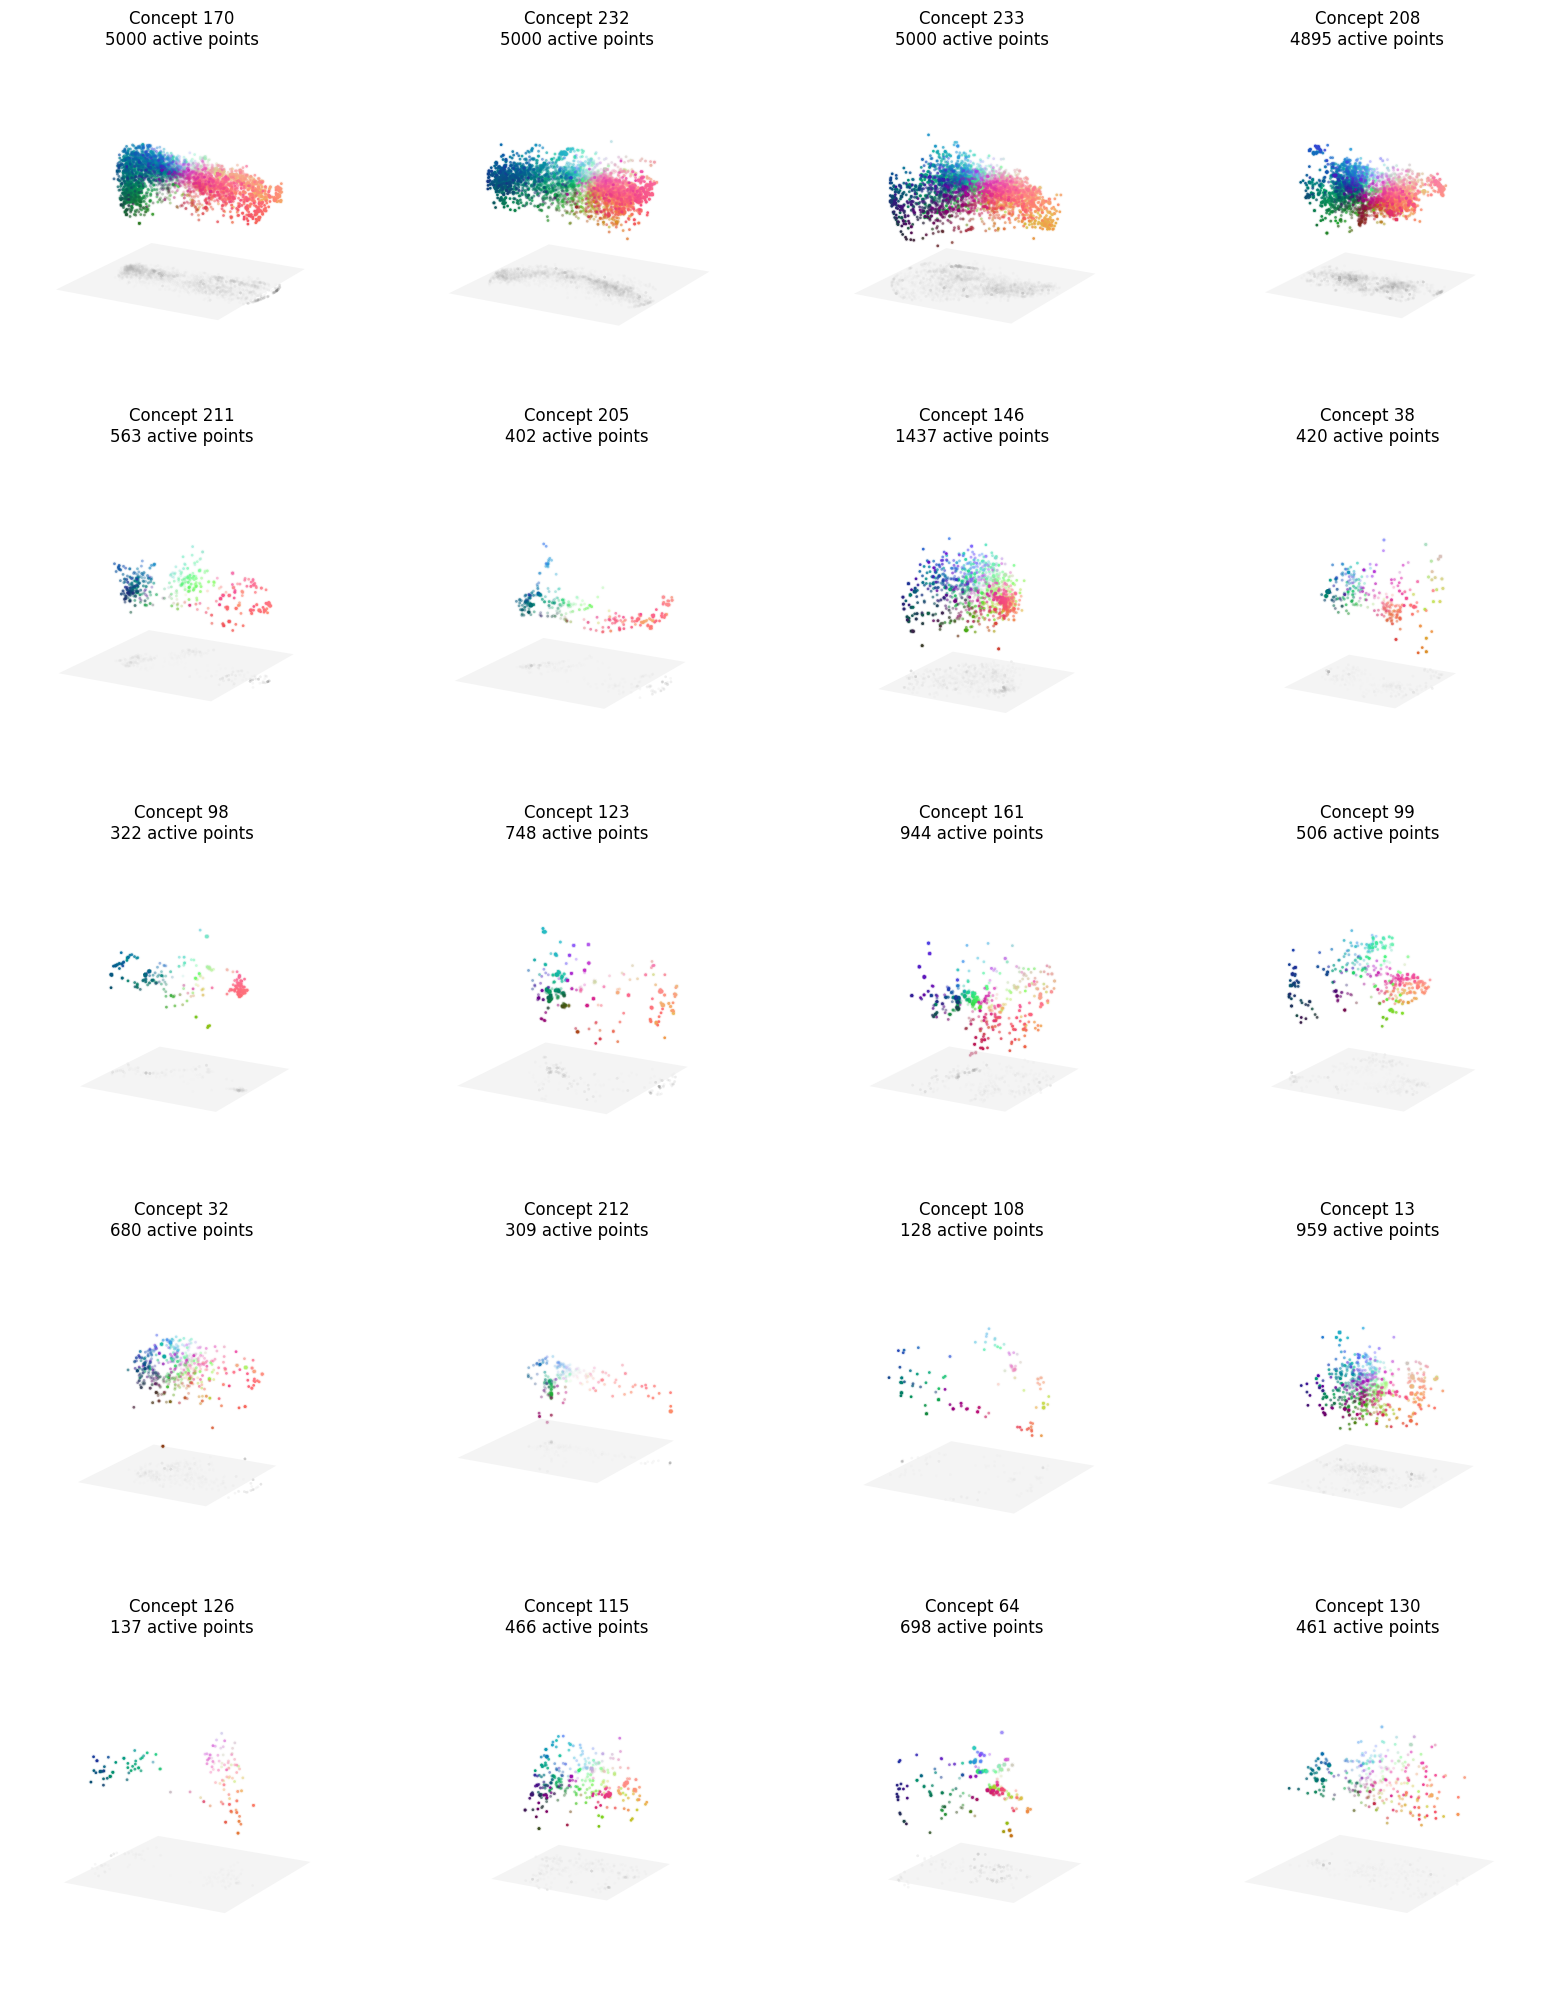

In [18]:
fig = plot_manifolds_only(
    z,
    atoms,
    top,
    ncols=4,
    point_size=4,
)

plt.show()